In [1]:
import pandas as pd

from lib.h_ensemble import build_ensemble_csv
from lib.plots import plot_uncertainty_distributions
from lib.utils import compute_uncertainties
import numpy as np
# load data 
""" MAIN SETTINGS AND DATA LOADING"""

dataset = 'ms_neuro'
analysis_name = 'ms_progression'
outcome_name = 'progression_independent_from_relapses'
build_ensemble_csv(analysis_name, outcome_name)


all_patients = pd.read_csv(f'../data/{dataset}/X.csv')
all_patients_y = pd.read_csv(f'../data/{dataset}/y.csv')

all_patients['label'] = all_patients_y[outcome_name].astype(int)


# load all predictions for the full training set (including active patients at bl)
patients_stats = pd.read_csv(f'../results/classification/{analysis_name}/{outcome_name}/aggregated/patient_mean_probs_{outcome_name}_{analysis_name}_model.csv')
patients_stats.index = patients_stats['idx']



# 1. Extract the inner list from each row using .str[0]
import ast

# 1. Convert the string representation "[0.8, 0.83...]" into a real Python list
real_lists = patients_stats['all_probs'].apply(ast.literal_eval)

# 2. Now expand those lists into columns
probs_raw_df = pd.DataFrame(real_lists.tolist(), index=patients_stats['idx'].values)

Skipping stacking as it's not in the list of models to include.
Skipping voting as it's not in the list of models to include.
Successfully aggregated 21600 predictions across 719 unique patients.


## Uncertainty Decomposition

Baseline entropy: 0.5120043783280033


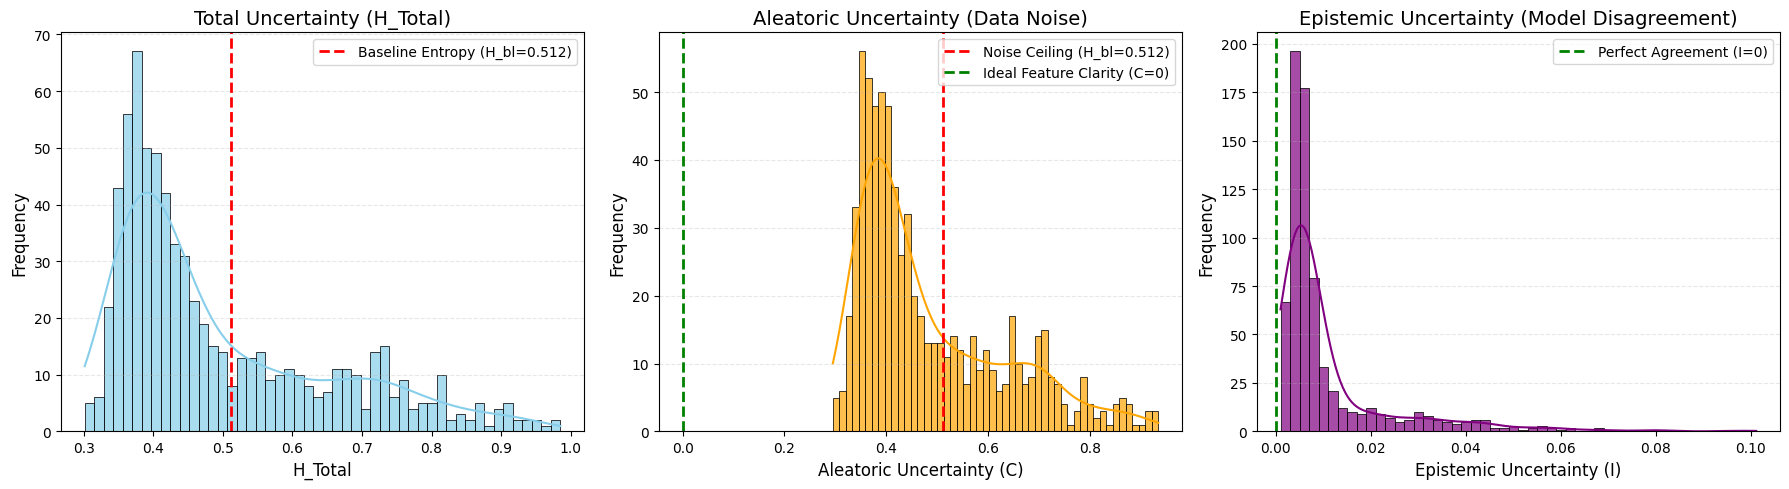

In [2]:
# Compute uncertainties for the non-active patients at baseline


uncertainty_results = compute_uncertainties(probs_raw_df, tau=0.11)

# Create an explicit copy to avoid SettingWithCopyWarning
patients_stats_copy = patients_stats.copy()

# 2. Add the results to your main stats table
patients_stats_copy['H_Total'] = uncertainty_results['H_Total']
patients_stats_copy['C_Aleatoric'] = uncertainty_results['C_Aleatoric']
patients_stats_copy['I_Epistemic'] = uncertainty_results['I_Epistemic']
patients_stats_copy['Distance_to_Tau'] = uncertainty_results['Distance_to_Tau']
patients_stats_copy['MW_H_Total'] = uncertainty_results['MW_H_Total']
# Compute the baseline risk (mean of probs_cal across all folds) for each patient and its uncertainty value 
proportion_positive = all_patients['label'].sum() / len(all_patients)
H_bl = -(proportion_positive * np.log2(proportion_positive + 1e-12) +
         (1 - proportion_positive) * np.log2(1 - proportion_positive + 1e-12))
print("Baseline entropy:", H_bl)



plot_uncertainty_distributions(
     patients_stats_copy, 
     H_bl, 
     #save_path='../results/uncertainty/plots/uncertainty_distributions.png'
 )

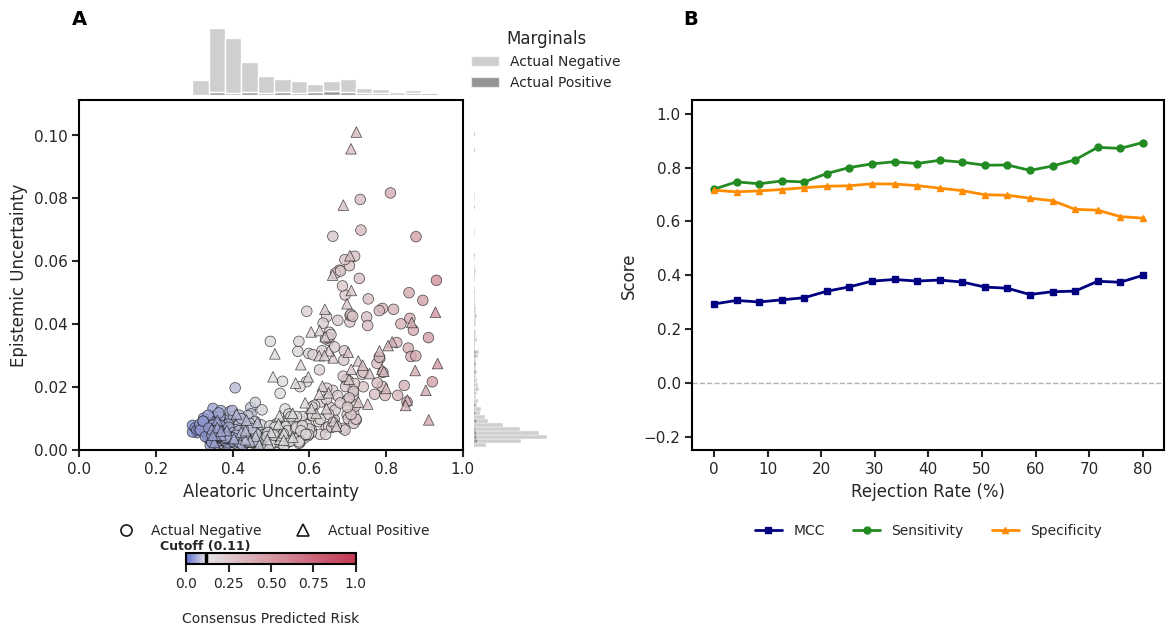

In [3]:
from lib.plots import plot_combined_uncertainty_analysis_v2


plot_combined_uncertainty_analysis_v2(patients_stats_copy,all_patients['label'], uncertainty_type='MW_H_Total')

## Explore clinical data through GMM analysis
No clear separation between patients. The two scores do not agree on the number of clusters. For this MS dataset we are going to skip the GMM analysis and rejection and move on to Conditioned Classification Rejection Curves (CCRC).

Number of original clinical features: 32
Optimal PCs according to the Kaiser Rule: 13

Top 5 Eigenvalues:
[3.54 2.69 2.57 2.04 1.76]


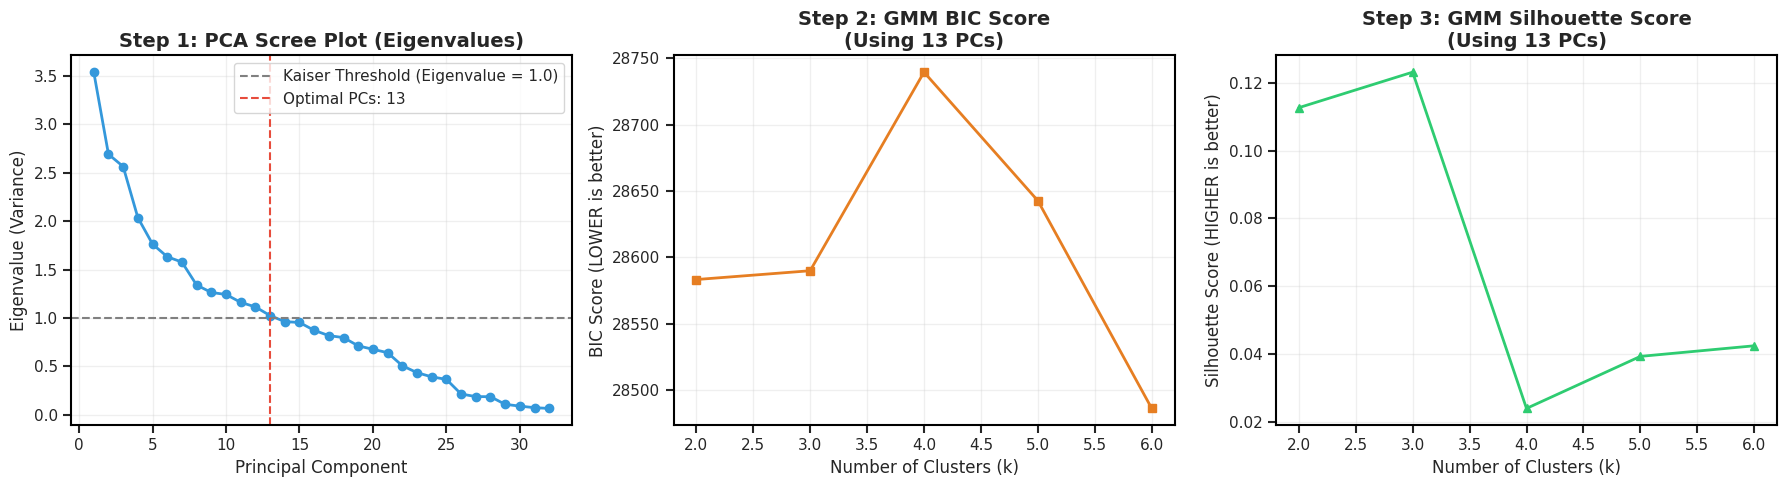


--- Optimization Results ---
1. Optimal PCs retained (Kaiser Rule, Eigenvalue > 1.0): 13
2. Best GMM model according to BIC (lowest complexity penalty): k = 6
3. Best GMM model according to Silhouette (highest separation): k = 3


In [7]:
from lib.clustering import optimize_pca_and_gmm_kaiser


optimize_pca_and_gmm_kaiser(X_clinical = all_patients.drop(['label'], axis=1), max_clusters=6)

## Conditioned Classification Rejection Curves (CCRC)

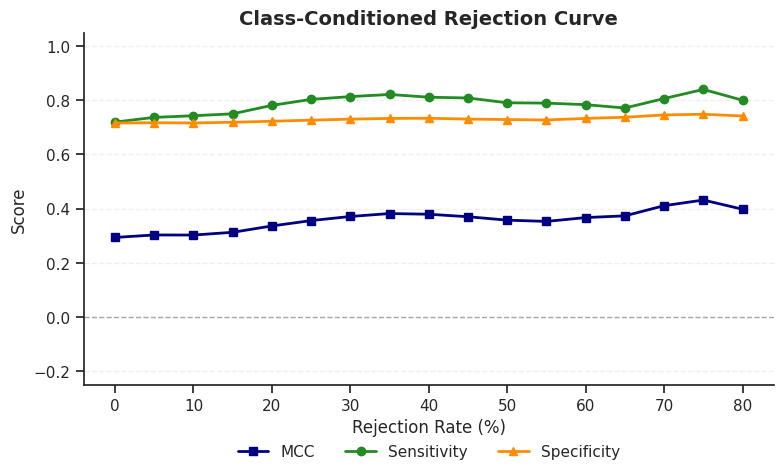

GLOBAL CLASS-CONDITIONED REJECTION: METRICS EVOLUTION
 Rejection (%)  Total Kept  TP  FP  TN  FN   MCC  Sensitivity  Specificity
             0         719  59 181 456  23 0.293        0.720        0.716
             5         684  56 172 436  20 0.303        0.737        0.717
            10         648  52 164 414  18 0.302        0.743        0.716
            15         612  51 153 391  17 0.312        0.750        0.719
            20         576  50 142 370  14 0.336        0.781        0.723
            25         540  49 131 348  12 0.356        0.803        0.727
            30         504  48 120 325  11 0.371        0.814        0.730
            35         468  46 110 302  10 0.382        0.821        0.733
            40         432  43 101 278  10 0.379        0.811        0.734
            45         396  38  94 255   9 0.370        0.809        0.731
            50         360  34  86 231   9 0.357        0.791        0.729
            55         324  30  78 208   8 0.3

In [4]:
from lib.plots import plot_class_conditioned_rejection_curve


optimal_threshold = all_patients['label'].mean()

class_cond_results = plot_class_conditioned_rejection_curve(
    patients_stats_copy, 
    threshold=optimal_threshold, 
    uncertainty_col='MW_H_Total',
    rates=np.linspace(0, 80, 17)
)

### Confusion matrix evolution analysis


Standard global rejection frameworks fail in clinical datasets because predicting the onset of a future disease (Class 1) is inherently noisier than diagnosing baseline stability (Class 0). This Asymmetric Aleatoric Uncertainty causes standard algorithms to disproportionately delete the positive class, crashing the Sensitivity to zero.

By implementing Class-Conditioned Rejection tied to the baseline prior, we successfully decoupled the rejection threshold from this asymmetric noise.

Dataset 1 (The Imbalanced Cohort | Prior ~0.11) -> The "Rescue" Mechanism

Observation: The baseline model struggles with the rare minority class (Sens: ~0.69, MCC: 0.27).

Impact: Class-Conditioned Rejection actively rescues the model. By dropping the top 25% of uncertain patients proportionally from both predicted classes, Sensitivity actually rises to ~0.76 and holds steady. We successfully deferred a quarter of the most ambiguous patients without artificially collapsing the rare disease class.

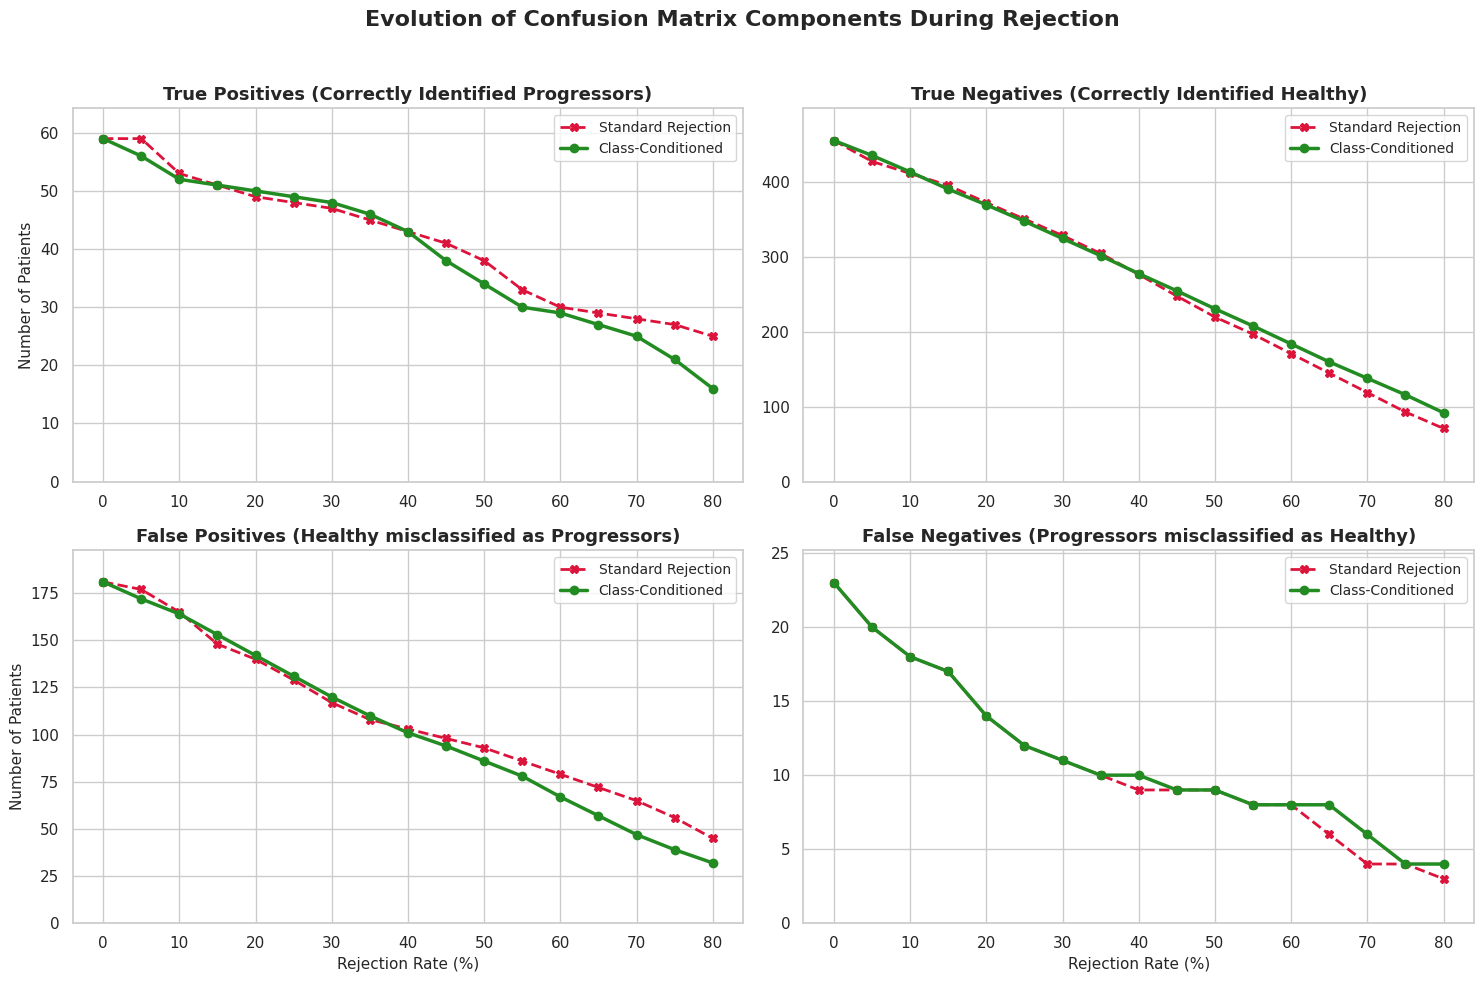

In [5]:

# Example Call:
from lib.plots import plot_comprehensive_rejection_dashboard


optimal_threshold = patients_stats_copy['label'].mean()
dashboard_results = plot_comprehensive_rejection_dashboard(patients_stats_copy, uncertainty_col='MW_H_Total', threshold=optimal_threshold)

In [6]:

from lib.utils import extract_and_analyze_rejection


optimal_threshold = patients_stats_copy['label'].mean()

# Extract the patients at a 25% rejection rate
kept_df, removed_df, uncertainty_stats = extract_and_analyze_rejection(
     patients_stats_copy, 
     prior_threshold=optimal_threshold, 
     rate=25, 
     method='class_conditioned',
     sort_col='H_Total',
     uncertainty_cols=['H_Total', 'C_Aleatoric', 'I_Epistemic', 'MW_H_Total']
)

REJECTION AUDIT: CLASS_CONDITIONED @ 25%
Total Cohort:    719 patients
Total Kept:      540 patients
Total Removed:   179 patients
--------------------------------------------------------------------------------
UNCERTAINTY PROFILE COMPARISON:
     Metric   Kept_Profile Removed_Profile P_Value
    H_Total  0.464 ± 0.128   0.592 ± 0.185  <0.001
C_Aleatoric  0.454 ± 0.121   0.577 ± 0.170  <0.001
I_Epistemic  0.010 ± 0.010   0.016 ± 0.020   0.433
 MW_H_Total 10.255 ± 4.934 17.768 ± 12.171  <0.001


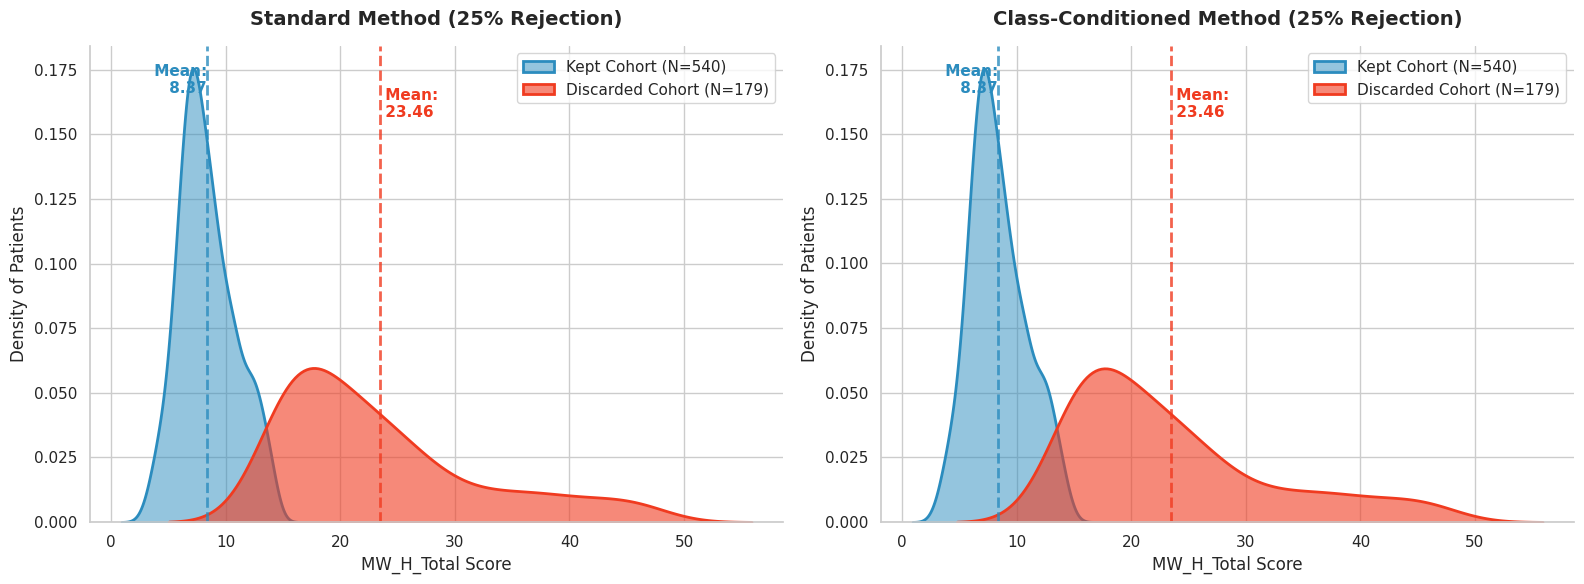

In [10]:


from lib.plots import plot_side_by_side_distributions


# --- Example Usage ---
optimal_threshold = patients_stats_copy['label'].mean()
plot_side_by_side_distributions(patients_stats_copy, uncertainty_col='MW_H_Total', threshold=optimal_threshold, rate=25)